# Imagenette, Imagewoof, and feature visualization

Frozen ResNet34 and DINOv2 ViT-S/14 with independent
Top-32 SAEs. Natural exemplars, optimized stimuli, and
controlled probes test feature hypotheses. These are
not reproductions of Distill circuits.

In [1]:
from pathlib import Path
import sys
import json
root = Path.cwd()
while not (root / 'src/lattmc/vision').is_dir():
    if root == root.parent:
        raise RuntimeError('Open within the repository')
    root = root.parent
sys.path.insert(0, str(root / 'src'))
paper = root / 'texs/sparsesurrs/visionlattices'

## Verify cached evidence

Check original image bytes and preprocessing, selected
features, cached codes, reconstruction, and query extents.
The standalone verifier also recomputes full backbone
inference and optimized-stimulus responses.

In [2]:
from lattmc.vision.verify_featureviz_codexgen import verify
print(json.dumps(verify(inference=False), indent=2))
for name in ['resnet34', 'dinov2']:
    folder = root / 'vision_tokens' / ('imagenette_' + name)
    result = json.loads((folder / 'results'
                         / 'experiment_codexgen.json')
                        .read_text())
    print(name, result['metrics'])

{
  "images": 450,
  "backbones": 2,
  "optimized_stimuli": 8,
  "synthetic_probes_per_model": 36,
  "full_inference": false
}
resnet34 {'train': {'count': 200, 'r2': 0.8932046294212341, 'site_l0': 32.0}, 'calibration': {'count': 50, 'r2': 0.8804590702056885, 'site_l0': 32.0}, 'test': {'count': 100, 'r2': 0.8779705166816711, 'site_l0': 32.0}, 'transfer': {'count': 100, 'r2': 0.881281852722168, 'site_l0': 32.0}}
dinov2 {'train': {'count': 200, 'r2': 0.8686758279800415, 'site_l0': 32.0}, 'calibration': {'count': 50, 'r2': 0.7096760272979736, 'site_l0': 32.0}, 'test': {'count': 100, 'r2': 0.7067857980728149, 'site_l0': 32.0}, 'transfer': {'count': 100, 'r2': 0.5956578254699707, 'site_l0': 32.0}}


## Natural photographs and site maps

Springer and church coordinates are selected from
Imagenette training labels. Imagewoof is a transfer
collection with no SAE retraining. Actual labels remain
visible, including mismatches.

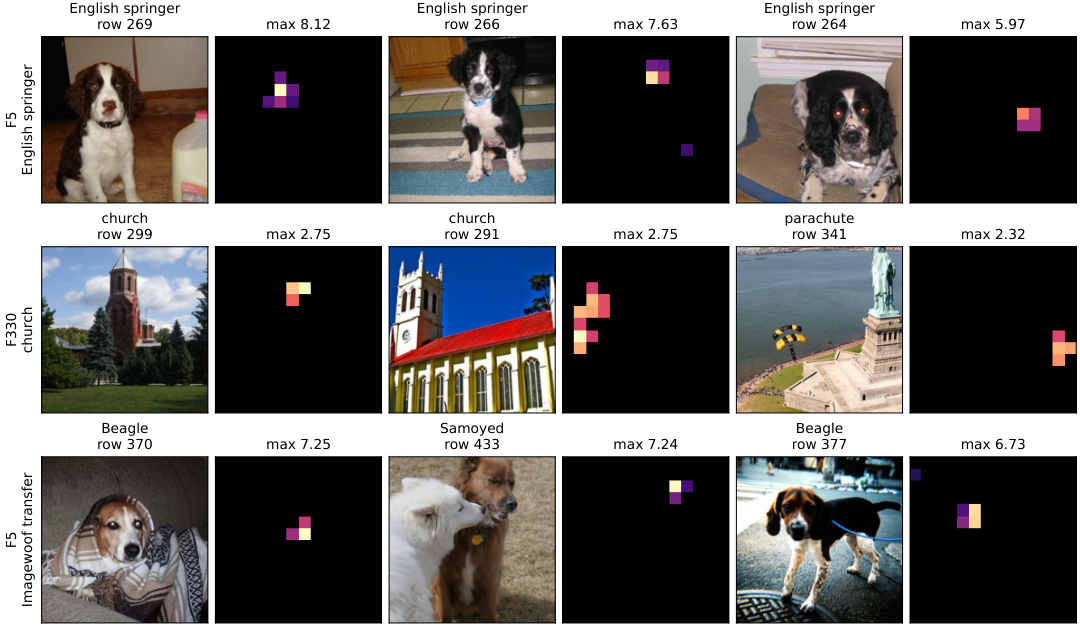

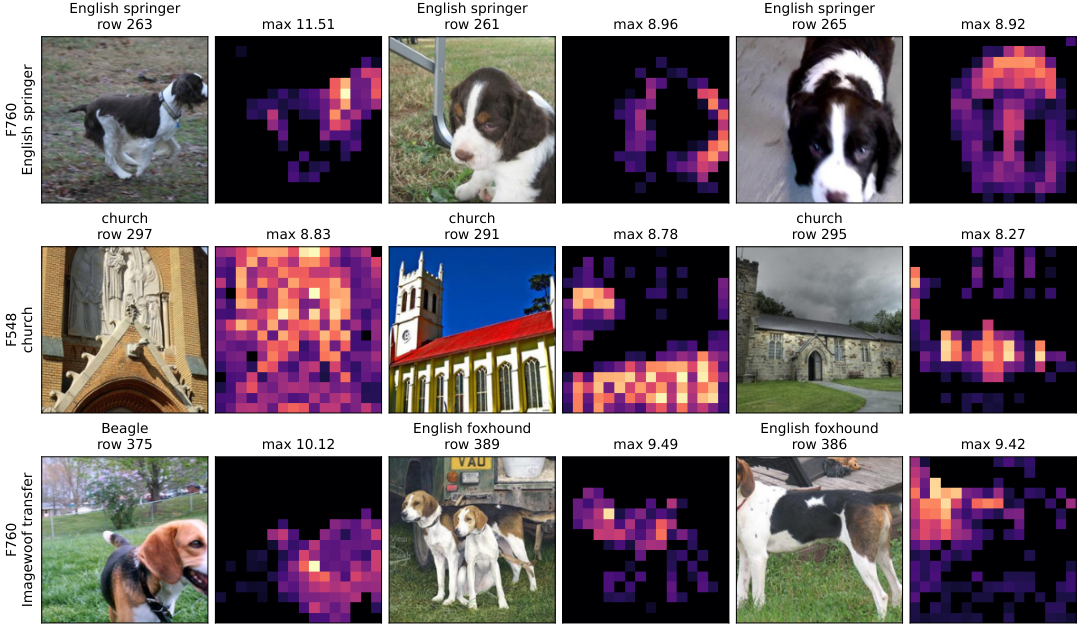

In [3]:
import pymupdf
from IPython.display import Image, display
def show(name):
    with pymupdf.open(paper / 'figures' / name) as doc:
        page = doc[0].get_pixmap(
            matrix=pymupdf.Matrix(1.25, 1.25), alpha=False)
        display(Image(data=page.tobytes('png')))
show('imagenette_resnet34_codexgen.pdf')
show('imagenette_dinov2_codexgen.pdf')

## Input optimization and controlled response tests

Optimization uses a smooth pre-Top-k proxy; reported
responses use actual sparse codes. Both random
initializations are shown. Curve, line, and corner
stimuli have matched mean brightness and RMS contrast.
Rotation of photographs also changes crop and sampling.

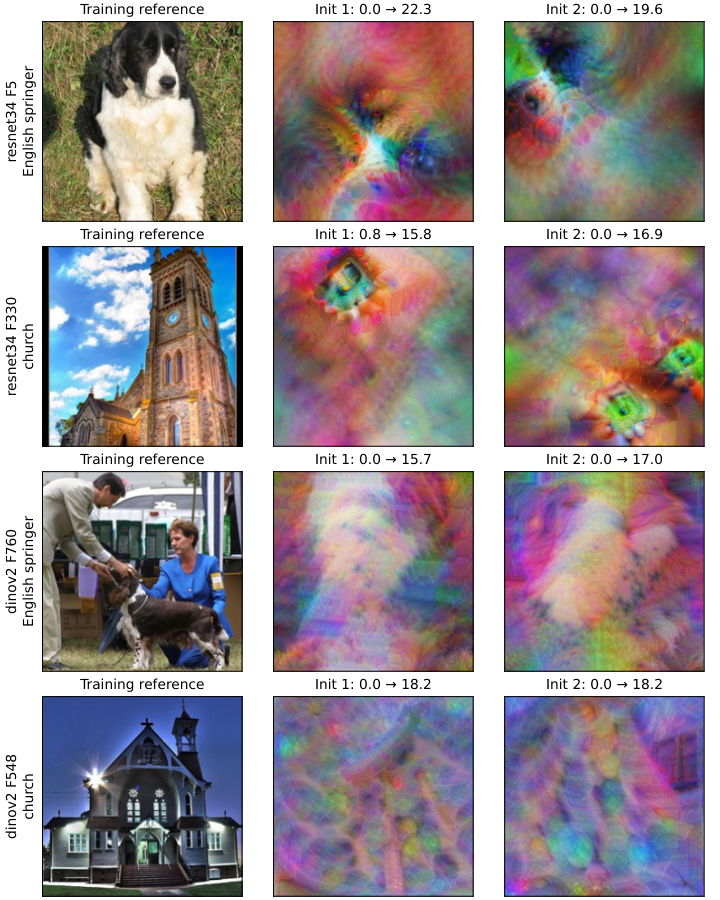

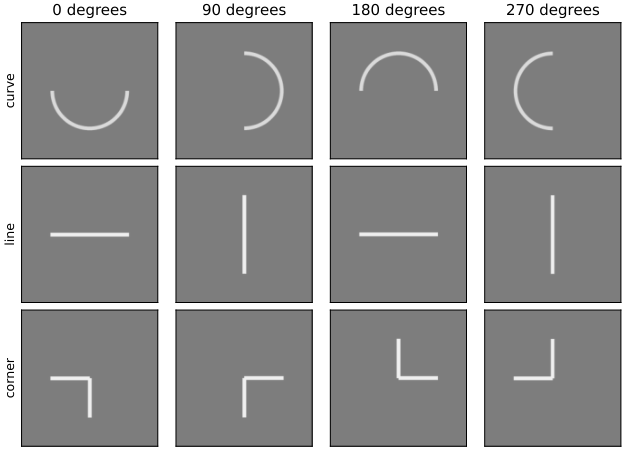

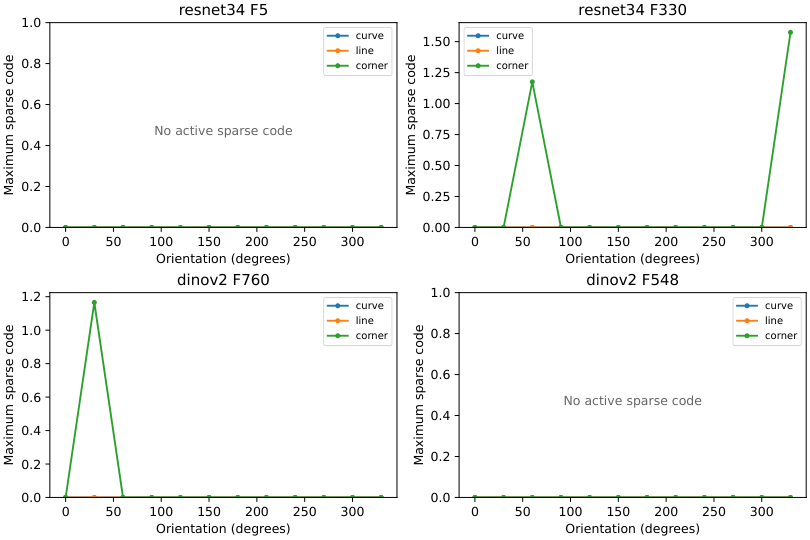

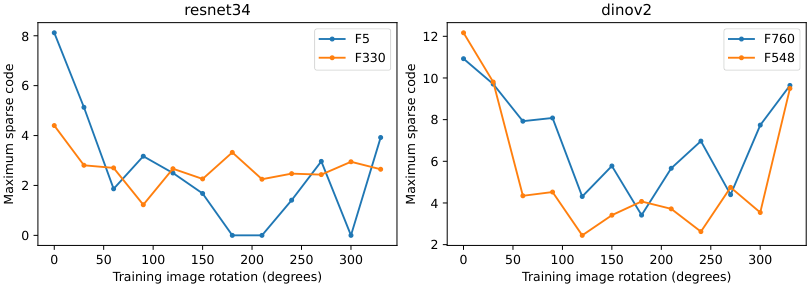

In [4]:
show('optimized_features_codexgen.pdf')
show('synthetic_stimuli_codexgen.pdf')
show('synthetic_tuning_codexgen.pdf')
show('rotation_tuning_codexgen.pdf')

## Reproduce

See vision_tokens/IMAGENETTE.md for complete commands,
upstream provenance, immutable model revision, and
limitations. The minimal environment adds Transformers
for DINOv2. No paid service or generative-image model is
used: stimuli come from differentiating the measured
backbones and sparse encoders.